# Multi-Feature LSTMS:

So far we used a single feature to predict a 1d outcome, what if we use use more than one?

In this example, instead of using them individually, we will use them all in one model.

We will use Open, Close, High and Low, to predict the Close prices.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout

In [ ]:
data = pd.read_csv('Google_train_data.csv')
data["Close"]=pd.to_numeric(data.Close,errors='coerce')
data = data.dropna()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [3]:
data["Close"]=pd.to_numeric(data.Close,errors='coerce')
data = data.dropna()

trainData = data.iloc[:,1:5].values

scMulti = MinMaxScaler(feature_range=(0,1))

trainData = scMulti.fit_transform(trainData)

In [4]:
X_train = []
y_train = []

for i in range (60,1149): #60 : timestep // 1149 : length of the data
    X_train.append(trainData[i-60:i]) 
    y_train.append(trainData[i])

X_train,y_train = np.array(X_train),np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(1089, 60, 4)
(1089, 4)


In [5]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],4)) #adding the batch_size axis
X_train.shape

(1089, 60, 4)

Use the hyperparameters we found when tuning:

In [ ]:
def create_and_train_model(X_train, y_train, epochs=20, batch_size=32, features = 1, dropout = 0.4, units = 100):
    # Define the model architecture
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=False, input_shape=(X_train.shape[1], features)))
    model.add(Dropout(dropout))
    model.add(Dense(units=features))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=2)

    return model, history

In [7]:
modelMulti, histMulti = create_and_train_model(X_train, y_train, features = 4, epochs=60, batch_size=128, units = 100, dropout = 0.4)

Epoch 1/60


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 - 1s - 154ms/step - loss: 0.1961
Epoch 2/60
9/9 - 0s - 47ms/step - loss: 0.0409
Epoch 3/60
9/9 - 0s - 47ms/step - loss: 0.0256
Epoch 4/60
9/9 - 0s - 49ms/step - loss: 0.0165
Epoch 5/60
9/9 - 0s - 49ms/step - loss: 0.0135
Epoch 6/60
9/9 - 0s - 48ms/step - loss: 0.0123
Epoch 7/60
9/9 - 0s - 48ms/step - loss: 0.0115
Epoch 8/60
9/9 - 0s - 48ms/step - loss: 0.0111
Epoch 9/60
9/9 - 0s - 50ms/step - loss: 0.0101
Epoch 10/60
9/9 - 1s - 63ms/step - loss: 0.0102
Epoch 11/60
9/9 - 1s - 67ms/step - loss: 0.0098
Epoch 12/60
9/9 - 0s - 53ms/step - loss: 0.0092
Epoch 13/60
9/9 - 0s - 52ms/step - loss: 0.0091
Epoch 14/60
9/9 - 1s - 97ms/step - loss: 0.0085
Epoch 15/60
9/9 - 1s - 59ms/step - loss: 0.0083
Epoch 16/60
9/9 - 0s - 54ms/step - loss: 0.0086
Epoch 17/60
9/9 - 0s - 50ms/step - loss: 0.0081
Epoch 18/60
9/9 - 0s - 51ms/step - loss: 0.0077
Epoch 19/60
9/9 - 0s - 54ms/step - loss: 0.0078
Epoch 20/60
9/9 - 1s - 56ms/step - loss: 0.0075
Epoch 21/60
9/9 - 0s - 49ms/step - loss: 0.0076
Epoch 22/60

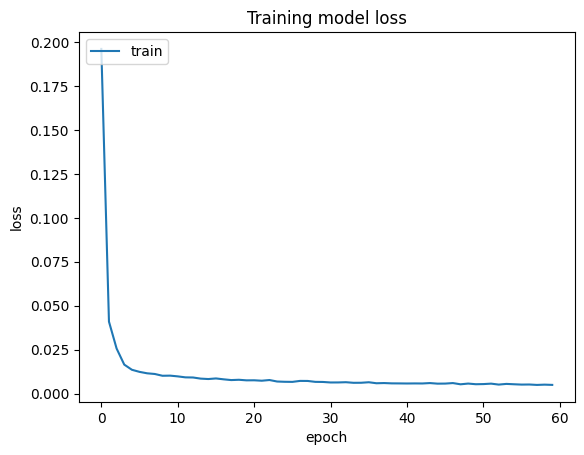

In [8]:
plt.plot(histMulti.history['loss'])
plt.title('Training model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

In [9]:
# Load and preprocess the test data
testDataMulti = pd.read_csv('Google_test_data.csv')
testDataMulti["Close"] = pd.to_numeric(testDataMulti.Close, errors='coerce')
testDataMulti = testDataMulti.dropna()

# Extract the relevant columns (Open, High, Low, Close)
testDataMulti = testDataMulti.iloc[:, 1:5]  # Assuming these are the columns for Open, High, Low, Close

# Prepare the y_test array (actual values to compare predictions with)
y_test_multi = testDataMulti.iloc[60:, :].values  # Actual values from the 60th row onwards

# Input array for the model
inputMulti = testDataMulti.values  # Full dataset as NumPy array
inputMulti_scaled = scMulti.transform(inputMulti)  # Scale the data
inputMulti_scaled.shape  # Shape: (length, 4)

# Prepare the X_test array
X_test = []
length = len(testDataMulti)
timestep = 60

for i in range(timestep, length):
    # Append the last 60 timesteps of all features for each row
    X_test.append(inputMulti_scaled[i-timestep:i, :])  # Shape: (60, 4)

# Convert to NumPy array and reshape
X_test = np.array(X_test)  # Convert to a NumPy array
print("X_test shape:", X_test.shape)  # Expected shape: (192, 60, 4)
print("y_test_multi shape:", y_test_multi.shape)  # Expected shape: (192, 4)

X_test shape: (192, 60, 4)
y_test_multi shape: (192, 4)


In [10]:
y_pred_multi = modelMulti.predict(X_test)
y_pred_multi.shape

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


(192, 4)

In [11]:
predicted_price_multi = scMulti.inverse_transform(y_pred_multi)

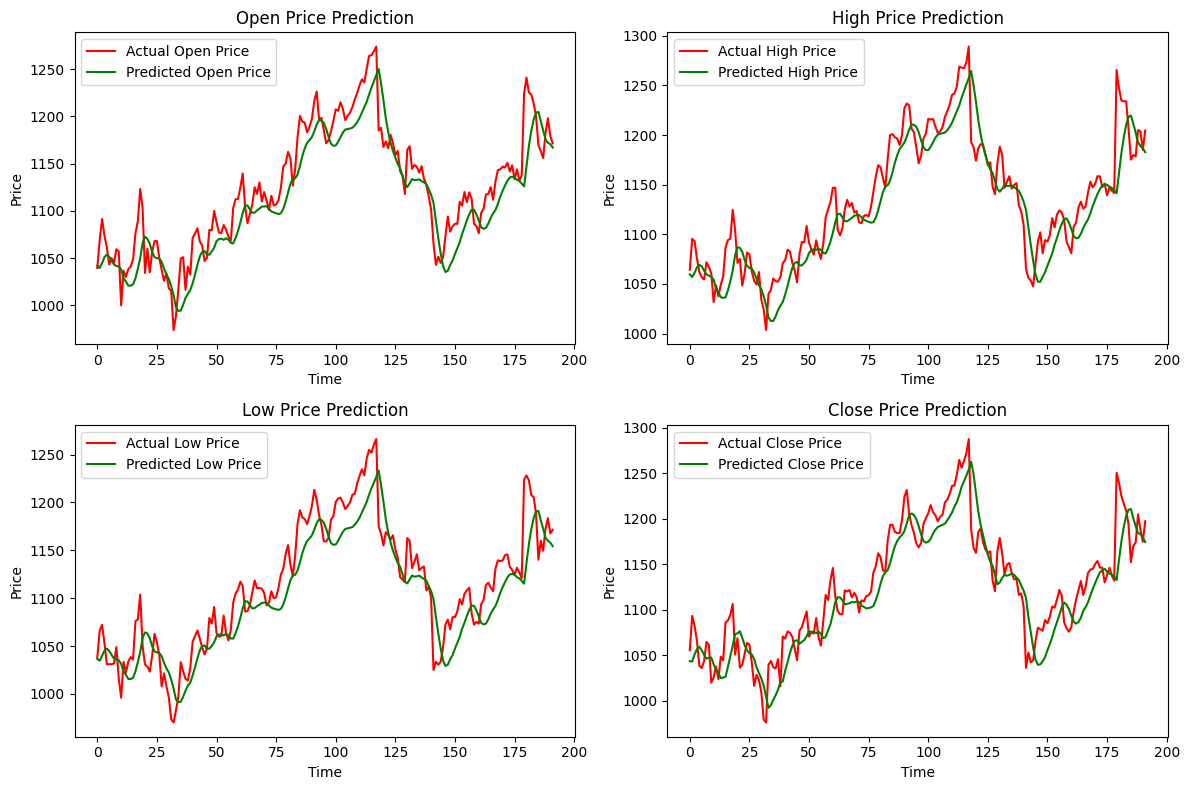

In [12]:
# Define feature names for better labeling
features = ['Open', 'High', 'Low', 'Close']

# Create subplots (2 rows x 2 columns)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Flatten axes array for easier indexing
axs = axs.ravel()

# Plot each feature
for i, feature in enumerate(features):
    axs[i].plot(y_test_multi[:, i], color='red', label=f'Actual {feature} Price')
    axs[i].plot(predicted_price_multi[:, i], color='green', label=f'Predicted {feature} Price')
    axs[i].set_title(f'{feature} Price Prediction')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Price')
    axs[i].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error

print("Open:")
print(mean_squared_error(y_test_multi[:,0], predicted_price_multi[:, 0]))

print("High:")
print(mean_squared_error(y_test_multi[:,1], predicted_price_multi[:, 1]))

print("Low:")
print(mean_squared_error(y_test_multi[:,2], predicted_price_multi[:, 2]))

print("Close:")
print(mean_squared_error(y_test_multi[:,3], predicted_price_multi[:, 3]))

print("All:")
print(mean_squared_error(y_test_multi, predicted_price_multi))


Open:
809.0241667471226
High:
760.9268995238511
Low:
886.7036818495832
Close:
843.806934076133
All:
825.1154205491723


Using a new data set:

In [53]:
data = pd.read_csv('tesla.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2193 non-null   object 
 1   Open       2193 non-null   float64
 2   High       2193 non-null   float64
 3   Low        2193 non-null   float64
 4   Close      2193 non-null   float64
 5   Adj Close  2193 non-null   float64
 6   Volume     2193 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 120.1+ KB


In [54]:
data.shape

(2193, 7)

In [55]:
data = data.iloc[:,1:6].values #to numpyarray

We have to make the split ourselves now for training vs testing. The standard is 80/20, so I will do that.

In [57]:
splitValue = int(len(data) * 0.8)
trainingData, testingData = data[:splitValue], data[splitValue:]

In [58]:
scMulti = MinMaxScaler(feature_range=(0,1))
trainingData = scMulti.fit_transform(trainingData)

In [59]:
X_train = []
y_train = []

for i in range (60,1149): #60 : timestep // 1149 : length of the data #we can adjsut the timestep??
    X_train.append(trainingData[i-60:i]) 
    y_train.append(trainingData[i])

X_train,y_train = np.array(X_train),np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(1089, 60, 5)
(1089, 5)


In [61]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],5)) #adding the batch_size axis
X_train.shape

(1089, 60, 5)

In [62]:
modelMulti, histMulti = create_and_train_model(X_train, y_train, features = 5, epochs=60, batch_size=64, units = 50, dropout = 0.2)

Epoch 1/60


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 - 1s - 69ms/step - loss: 0.0617
Epoch 2/60
18/18 - 0s - 20ms/step - loss: 0.0097
Epoch 3/60
18/18 - 0s - 19ms/step - loss: 0.0053
Epoch 4/60
18/18 - 0s - 17ms/step - loss: 0.0044
Epoch 5/60
18/18 - 0s - 21ms/step - loss: 0.0045
Epoch 6/60
18/18 - 0s - 20ms/step - loss: 0.0036
Epoch 7/60
18/18 - 0s - 20ms/step - loss: 0.0035
Epoch 8/60
18/18 - 0s - 18ms/step - loss: 0.0032
Epoch 9/60
18/18 - 0s - 19ms/step - loss: 0.0027
Epoch 10/60
18/18 - 0s - 19ms/step - loss: 0.0030
Epoch 11/60
18/18 - 0s - 19ms/step - loss: 0.0032
Epoch 12/60
18/18 - 0s - 19ms/step - loss: 0.0027
Epoch 13/60
18/18 - 0s - 19ms/step - loss: 0.0025
Epoch 14/60
18/18 - 0s - 20ms/step - loss: 0.0026
Epoch 15/60
18/18 - 0s - 19ms/step - loss: 0.0025
Epoch 16/60
18/18 - 0s - 19ms/step - loss: 0.0021
Epoch 17/60
18/18 - 0s - 19ms/step - loss: 0.0020
Epoch 18/60
18/18 - 0s - 19ms/step - loss: 0.0021
Epoch 19/60
18/18 - 0s - 18ms/step - loss: 0.0021
Epoch 20/60
18/18 - 0s - 18ms/step - loss: 0.0020
Epoch 21/60
18/18 - 

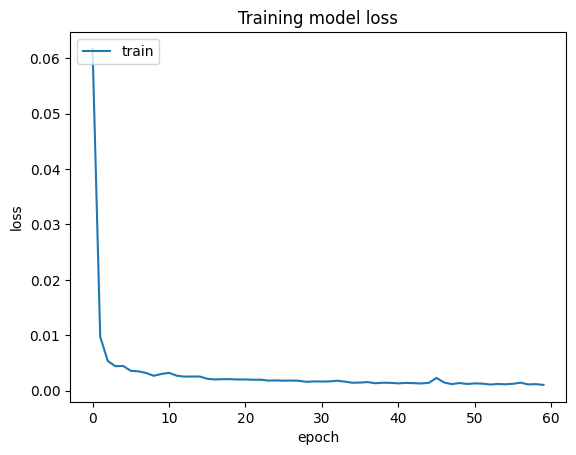

In [63]:
plt.plot(histMulti.history['loss'])
plt.title('Training model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

In [69]:
# Prepare the y_test array (actual values to compare predictions with)
y_test_multi = testingData[60:, :]  # Actual values from the 60th row onwards

# Input array for the model
inputMulti = testingData  # Full dataset as NumPy array
inputMulti_scaled = scMulti.transform(inputMulti)  # Scale the data
inputMulti_scaled.shape  # Shape: (length, 4)

# Prepare the X_test array
X_test = []
length = len(testingData)
timestep = 60

for i in range(timestep, length):
    # Append the last 60 timesteps of all features for each row
    X_test.append(inputMulti_scaled[i-timestep:i, :])  # Shape: (60, 4)

# Convert to NumPy array and reshape
X_test = np.array(X_test)  # Convert to a NumPy array
print("X_test shape:", X_test.shape)  # Expected shape: (192, 60, 4)
print("y_test_multi shape:", y_test_multi.shape)  # Expected shape: (192, 4)

X_test shape: (379, 60, 5)
y_test_multi shape: (379, 5)


In [70]:
y_pred_multi = modelMulti.predict(X_test)
y_pred_multi.shape

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


(379, 5)

In [71]:
predicted_price_multi = scMulti.inverse_transform(y_pred_multi)

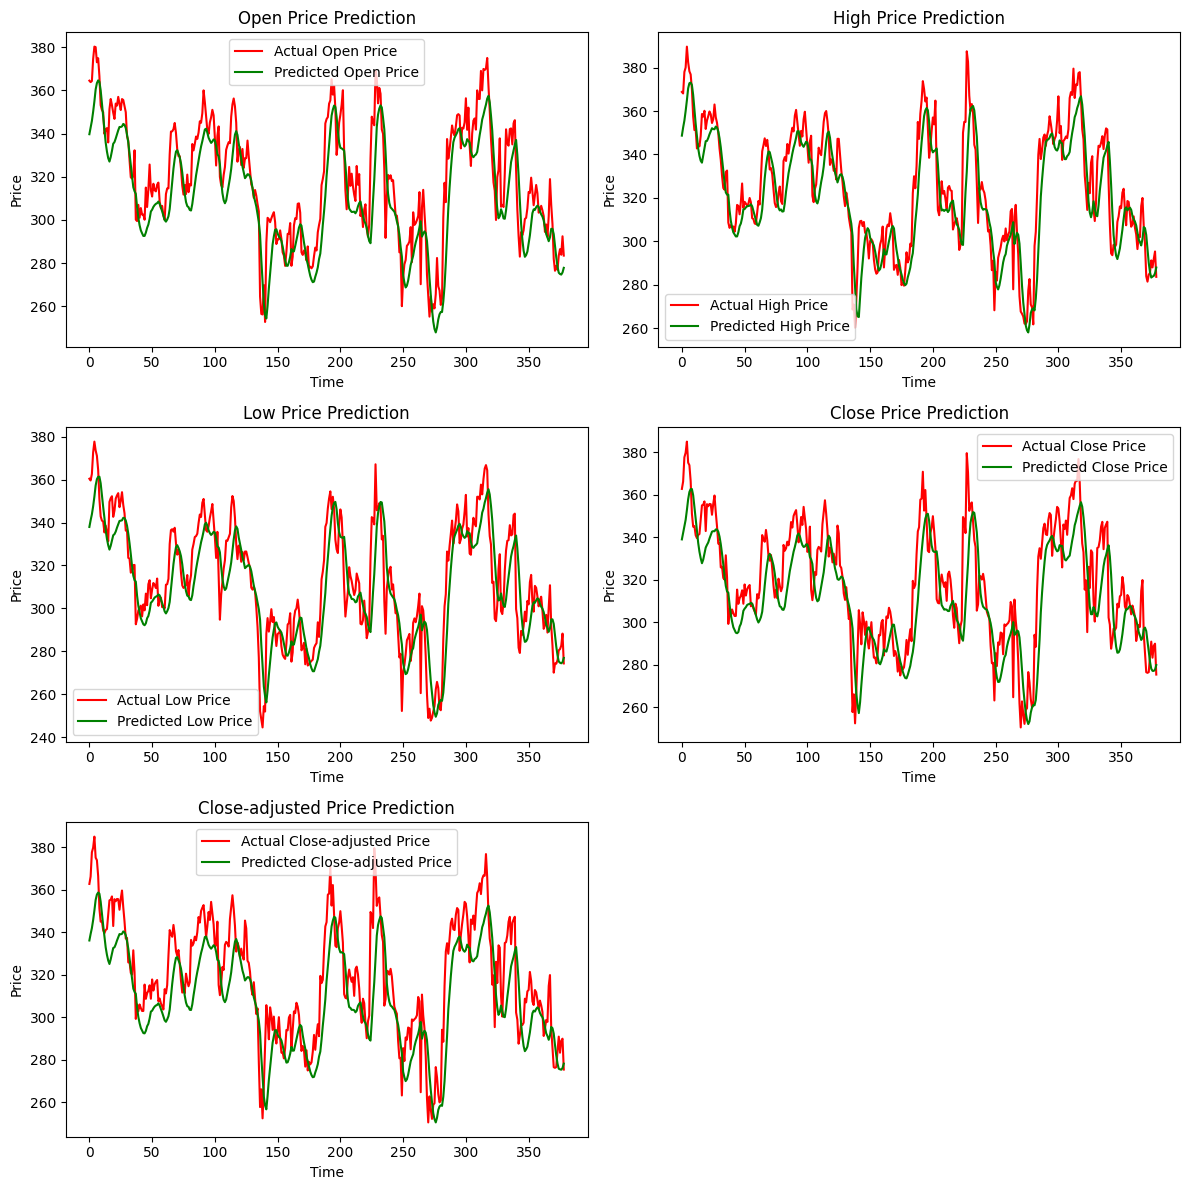

In [73]:
# Define feature names for better labeling
features = ['Open', 'High', 'Low', 'Close', 'Close-adjusted']

# Create subplots (3 rows x 2 columns)
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# Flatten axes array for easier indexing
axs = axs.ravel()

# Plot each feature
for i, feature in enumerate(features):
    axs[i].plot(y_test_multi[:, i], color='red', label=f'Actual {feature} Price')
    axs[i].plot(predicted_price_multi[:, i], color='green', label=f'Predicted {feature} Price')
    axs[i].set_title(f'{feature} Price Prediction')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Price')
    axs[i].legend()

# Turn off the last subplot (unused)
axs[-1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()
